# External Validation on GSE70769 (Rank-Based & Common Genes) — Revised

This notebook improves on the original external-validation pipeline. Key changes vs. the previous version:

1. **Fixed an import bug** — `rankdata` lives in `scipy.stats`, not `sklearn.preprocessing`; the original import would have raised an `ImportError`.
2. **Reproducible gene set** — common genes are now sorted instead of taken from an unordered Python `set`, whose iteration order is not guaranteed to be stable across runs.
3. **Data quality checks** — zero-variance genes are dropped and any missing values are median-imputed (fit on the TCGA cohort only) before modeling.
4. **Corrected normalization axis** — rank normalization is now computed **per gene, across samples** (`axis=0`) instead of per sample across genes. This is what actually aligns each gene's distribution between platforms; the per-sample version in the original notebook did not address cross-platform batch effects in the way the markdown claimed. Ranks are also scaled to [0, 1] for numerical stability.
5. **Feature selection** — with far more genes than samples, an unconstrained logistic regression is prone to overfitting. A univariate ANOVA F-test (`SelectKBest`) now selects the most informative genes, fit only on the training cohort.
6. **Hyperparameter tuning** — the number of selected genes and the regularization strength `C` are tuned via 5-fold stratified cross-validation on the TCGA training data, with `class_weight='balanced'` to handle any class imbalance.
7. **Stratified bootstrap** — the AUC confidence interval now resamples within each class, preserving BCR prevalence in every replicate instead of discarding replicates that happen to lack one class.
8. **Extra diagnostics** — a Brier score is reported alongside AUC, and the selected genes are inspected by coefficient magnitude for interpretability.

Steps:
1. Load pre-aligned GSE70769 data and TCGA training data.
2. Identify common genes, drop zero-variance features, impute missing values.
3. Apply per-gene rank normalization (scaled to [0, 1]) to mitigate platform/batch effects.
4. Select informative genes and tune a regularized Logistic Regression via cross-validation.
5. Evaluate on the external cohort with AUC, Brier score, and a stratified bootstrap CI.

In [19]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import config
from src.io import save_figure, logger

In [20]:
# Load Pre-Aligned Data from INTERIM directory (Correct Path & Filenames)
X_gse_full = pd.read_csv(config.INTERIM_DIR / "GSE70769_expression_full.csv", index_col=0)
y_gse = pd.read_csv(config.INTERIM_DIR / "GSE70769_bcr_target.csv", index_col=0).iloc[:, 0]

# Load TCGA Training Data (Robust Loading for y_train)
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv", index_col=0)

# ROBUST FIX for y_train loading
y_train_path = config.PROCESSED_DIR / "y_train.csv"
y_train_df = pd.read_csv(y_train_path, index_col=0)

if y_train_df.shape[1] == 0:
    # Case 1: File had only 1 column which became the index
    y_train = y_train_df.reset_index().iloc[:, 0] 
else:
    # Case 2: File has data columns; take the first one
    y_train = y_train_df.iloc[:, 0]

logger.info(f"TCGA Train Shape: {X_train.shape}")
logger.info(f"GSE70769 Shape: {X_gse_full.shape}")
logger.info(f"TCGA BCR Distribution:\n{y_train.value_counts()}")
logger.info(f"GSE BCR Distribution:\n{y_gse.value_counts()}")

2026-08-31 03:06:40 | INFO     | prostate_bcr | TCGA Train Shape: (343, 19018)
2026-08-31 03:06:40 | INFO     | prostate_bcr | GSE70769 Shape: (94, 29720)
2026-08-31 03:06:40 | INFO     | prostate_bcr | TCGA BCR Distribution:
Biochemical_Recurrence_Code
0    297
1     46
Name: count, dtype: int64
2026-08-31 03:06:40 | INFO     | prostate_bcr | GSE BCR Distribution:
biochemical relapse (bcr)
0    49
1    45
Name: count, dtype: int64


In [21]:
# Identify Common Genes (sorted for run-to-run reproducibility)
non_gene_prefixes = ('Gleason', 'Margin', 'T_Stage')
common_genes = sorted(
    g for g in (set(X_train.columns) & set(X_gse_full.columns))
    if not g.startswith(non_gene_prefixes)
)

logger.info(f"Number of Common Genes: {len(common_genes)}")

# Subset Data
X_train_common = X_train[common_genes].copy()
X_gse_common = X_gse_full[common_genes].copy()

# Drop genes with zero variance in either cohort (uninformative, and can
# break rank-based scaling / feature selection)
zero_var_genes = set(X_train_common.columns[X_train_common.var() == 0]) \
    | set(X_gse_common.columns[X_gse_common.var() == 0])

if zero_var_genes:
    logger.info(f"Dropping {len(zero_var_genes)} zero-variance genes.")
    common_genes = [g for g in common_genes if g not in zero_var_genes]
    X_train_common = X_train_common[common_genes]
    X_gse_common = X_gse_common[common_genes]

# Median-impute any missing values, fit on the training cohort only
imputer = SimpleImputer(strategy="median")
X_train_common = pd.DataFrame(
    imputer.fit_transform(X_train_common),
    index=X_train_common.index, columns=common_genes,
)
X_gse_common = pd.DataFrame(
    imputer.transform(X_gse_common),
    index=X_gse_common.index, columns=common_genes,
)

2026-08-31 03:06:40 | INFO     | prostate_bcr | Number of Common Genes: 15064


In [22]:
# Rank-Based Normalization (per gene, scaled to [0, 1])
#
# Each gene's expression is ranked across the samples *within its own
# cohort*, then scaled to [0, 1]. This makes a given gene's relative
# position in its cohort's distribution comparable across platforms, even
# when the two platforms have very different absolute scales — which is
# what mitigating a batch/platform effect actually requires. (Ranking
# within a sample across genes, as in the original version, does not
# address this.)
def rank_normalize(df: pd.DataFrame) -> pd.DataFrame:
    ranked = df.apply(lambda col: rankdata(col), axis=0)
    scaled = (ranked - 1) / (len(df) - 1)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

X_train_ranked = rank_normalize(X_train_common)
X_gse_ranked = rank_normalize(X_gse_common)

logger.info("Rank-based normalization applied (per-gene, scaled to [0, 1]).")

2026-08-31 03:06:44 | INFO     | prostate_bcr | Rank-based normalization applied (per-gene, scaled to [0, 1]).


In [23]:
# Feature Selection + Hyperparameter Tuning (cross-validated on TCGA only)
#
# With far more genes than samples, fitting logistic regression on every
# common gene invites overfitting. SelectKBest (ANOVA F-test) narrows the
# feature set, and both the number of genes kept and the regularization
# strength C are chosen by 5-fold stratified CV on the training cohort.
pipeline = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", LogisticRegression(
        random_state=config.RANDOM_STATE,
        max_iter=5000,
        class_weight="balanced",
    )),
])

candidate_k = sorted({k for k in (50, 100, 200, 500) if k < len(common_genes)} | {len(common_genes)})

param_grid = {
    "select__k": candidate_k,
    "clf__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1,
)
grid_search.fit(X_train_ranked, y_train)

logger.info(f"Best CV AUC (TCGA internal): {grid_search.best_score_:.4f}")
logger.info(f"Best Params: {grid_search.best_params_}")

model_ext = grid_search.best_estimator_

2026-08-31 03:06:57 | INFO     | prostate_bcr | Best CV AUC (TCGA internal): 0.6985
2026-08-31 03:06:57 | INFO     | prostate_bcr | Best Params: {'clf__C': 0.01, 'select__k': 500}


In [24]:
# Predict on External Cohort
y_prob_gse = model_ext.predict_proba(X_gse_ranked)[:, 1]
auc_gse = roc_auc_score(y_gse, y_prob_gse)
brier_gse = brier_score_loss(y_gse, y_prob_gse)

logger.info(f"External Validation AUC (Rank-Based, tuned): {auc_gse:.4f}")
logger.info(f"External Validation Brier Score: {brier_gse:.4f}")

2026-08-31 03:06:57 | INFO     | prostate_bcr | External Validation AUC (Rank-Based, tuned): 0.5751
2026-08-31 03:06:57 | INFO     | prostate_bcr | External Validation Brier Score: 0.2592


In [25]:
# Stratified Bootstrap Confidence Interval
#
# Resampling within each class preserves the external cohort's BCR
# prevalence in every bootstrap replicate, avoiding both a source of extra
# variance and the need to discard replicates that lack one class.
rng = np.random.RandomState(config.RANDOM_STATE)
n_bootstraps = 2000

y_gse_arr = y_gse.to_numpy()
class_indices = {c: np.where(y_gse_arr == c)[0] for c in np.unique(y_gse_arr)}

bootstrapped_aucs = []
for _ in range(n_bootstraps):
    boot_idx = np.concatenate([
        rng.choice(idx, size=len(idx), replace=True)
        for idx in class_indices.values()
    ])
    auc_boot = roc_auc_score(y_gse_arr[boot_idx], y_prob_gse[boot_idx])
    bootstrapped_aucs.append(auc_boot)

ci_low = np.percentile(bootstrapped_aucs, 2.5)
ci_high = np.percentile(bootstrapped_aucs, 97.5)

logger.info(f"Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

2026-08-31 03:06:59 | INFO     | prostate_bcr | Bootstrap 95% CI: [0.4558, 0.6966]


2026-08-31 03:06:59 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\external_validation_roc_rankbased.png


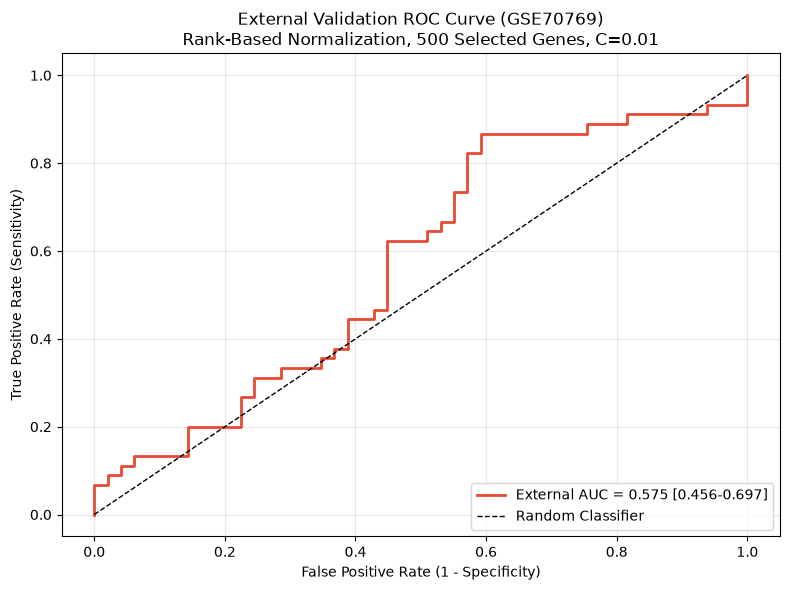

In [26]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_gse, y_prob_gse)
n_selected = grid_search.best_params_["select__k"]
best_c = grid_search.best_params_["clf__C"]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#E64B35', lw=2,
         label=f'External AUC = {auc_gse:.3f} [{ci_low:.3f}-{ci_high:.3f}]')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(
    f'External Validation ROC Curve (GSE70769)\n'
    f'Rank-Based Normalization, {n_selected} Selected Genes, C={best_c}'
)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_figure(plt.gcf(), "external_validation_roc_rankbased.png")
plt.show()

In [27]:
# Inspect Selected Genes & Their Coefficients
selector = model_ext.named_steps["select"]
clf = model_ext.named_steps["clf"]
selected_mask = selector.get_support()
selected_genes = np.array(common_genes)[selected_mask]

coef_df = pd.DataFrame({
    "gene": selected_genes,
    "coefficient": clf.coef_[0],
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

logger.info(f"Top 10 genes by |coefficient|:\n{coef_df.head(10).to_string(index=False)}")
coef_df.head(20)

2026-08-31 03:06:59 | INFO     | prostate_bcr | Top 10 genes by |coefficient|:
   gene  coefficient
TP53I13    -0.097154
SULT1A3     0.081626
  OR3A2    -0.078381
  PPWD1    -0.074640
   AREG     0.073402
 ZRANB1     0.071524
   GCGR    -0.069389
   CDH8     0.069114
 SLC5A2     0.065961
  RBMX2    -0.064912


,gene,coefficient
0,TP53I13,-0.097154
1,SULT1A3,0.081626
2,OR3A2,-0.078381
3,PPWD1,-0.074640
4,AREG,0.073402
5,ZRANB1,0.071524
6,GCGR,-0.069389
7,CDH8,0.069114
8,SLC5A2,0.065961
9,RBMX2,-0.064912
